In [1]:
import numpy as np
import matplotlib.pyplot as plt
from empymod import bipole

We define a function that is doing the forward calculation for a thickness vector and resistivity vector.

In [2]:
def forward(res, thk, L=40, time=None):
    """Compute TEM forward response for given resistivity and thickness.

    Parameter
    ---------
    res : array
        this is my resistivity (but only subsurface)
    thk : array (one shorter than res)
        thickness of the (N-1) layers (last is infinite)
    L : float [40]
        loop edge length
    time : array
        gate time at which transient is measured
    """
    if time is None:
        time = np.logspace(-6, -2, 41)

    tx = [-L/2, L/2, L/2, -L/2, -L/2]
    ty = [L/2, L/2, -L/2, -L/2, L/2]
    return bipole(res=np.concatenate([[2e14], res]),
        depth=np.concatenate([[0], np.cumsum(thk)]), # convert thickness into depths! (cumsum) [0], cumsum(...)
        src=[tx[:-1], tx[1:], ty[:-1], ty[1:], 0, 0],
        rec=[0, 0, 0, 0, 90],
        signal=-1,
        strength=1/L**2,
        mrec="b",
        verb=0, # silent
        freqtime=time, # Wanted times.
        srcpts=3,
        ftarg={"dlf": "key_81_2009"},  # Shorter, faster filters.
        # htarg={"dlf": "key_101_2009", "pts_per_dec": -1},
        ).sum(axis=1)

We model a homogeneous half-space and a model with a good conductor. Play with it!

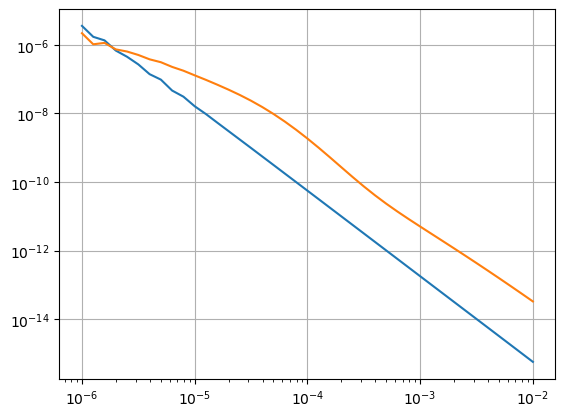

In [7]:
time = np.logspace(-6, -2, 41)
dataH = forward([200, 200, 200], [20, 20]);#, L=100)
data = forward([200, 10, 200, 10], [10, 20, 50]);#, L=100)
plt.loglog(time, dataH)
plt.loglog(time, data)
plt.grid();

We should now add some noise onto the data:

In [8]:
error = 0.03
dataN = data * (np.random.normal(0, error, len(data)) + 1)  # or randn(len(data)) * error + 1

For a better view on the curve, one can also look at the apparent resistivity.

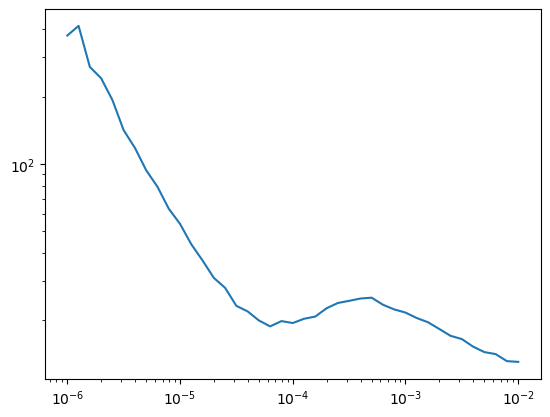

In [9]:
def rhoa(t, dbzdt, m=1.0):
    mu0 = 4e-7 * np.pi
    return mu0/np.pi*(mu0*m/20)**(2/3)*np.abs(dbzdt)**(-2/3)*t**(-5/3)

plt.loglog(time, rhoa(time, dataN));

We perform a grid search testing a range of parameters for $d_2$ and $\rho_2$.
To display the results, we create a function.

In [31]:
def showPhiD(x, y, mat, xlabel=r"$\rho_2$ ($\Omega$m)", ylabel=r"$d_2$ (m)",
             vmin=1, vmax=4, orientation="vertical", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    im = ax.matshow(mat, cmap="Spectral_r", vmin=vmin, vmax=vmax)
    xt = np.arange(0, len(x), 5)
    xtl = ["{:.0f}".format(np.round(xx)) for xx in x[xt]]
    yt = np.arange(0, len(y), 5)
    ytl = ["{:.0f}".format(np.round(yy)) for yy in y[yt]]
    plt.xticks(xt, xtl)
    plt.yticks(yt, ytl)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.xaxis.set_ticks_position("bottom")
    cb = plt.colorbar(im, orientation=orientation)

    return ax, cb

In [32]:
phiD = lambda x, y, err: np.mean((np.log(x)-np.log(y))**2/err**2)
thk2 = np.logspace(0.5, 2, 31)
res2 = np.logspace(0.5, 2, 31)
M = np.zeros((len(thk2), len(res2)))
res = [200, 200, 200]
thk = [20, 20]
error = 0.02
dataN = data * (1+np.random.randn(len(data))*error)
for i, res[1] in enumerate(thk2):
    for j, thk[1] in enumerate(res2):
        M[i, j] = phiD(data, forward(res, thk), error)

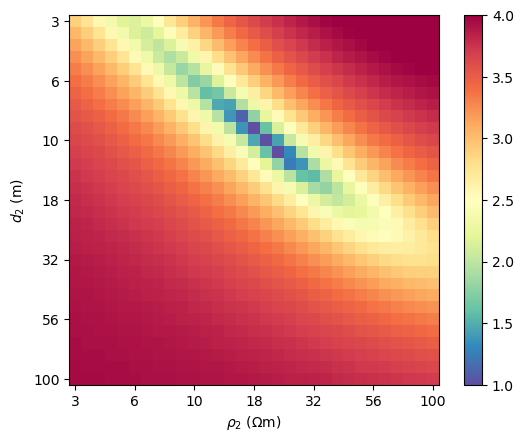

In [33]:
showPhiD(res2, thk2, np.log10(M), vmin=1, vmax=4);

We now create a model with a pre-defined thickness vector and invert only for the resistivity, starting with a homogeneous vector.

In [64]:
# thk = np.arange(5.0, 100, 5)
# thk = np.ones(20) * 5
thk = np.linspace(2., 25, 20)
print(np.cumsum(thk))
res = np.ones(len(thk)+1)*100

[  2.           5.21052632   9.63157895  15.26315789  22.10526316
  30.15789474  39.42105263  49.89473684  61.57894737  74.47368421
  88.57894737 103.89473684 120.42105263 138.15789474 157.10526316
 177.26315789 198.63157895 221.21052632 245.         270.        ]


In [65]:
response = forward(res, thk)

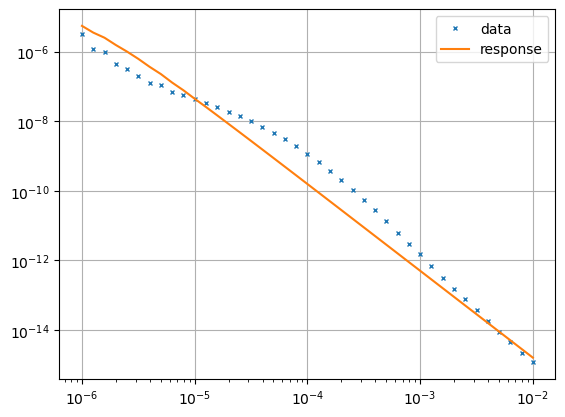

In [66]:
plt.loglog(time, dataN, "x", label="data")
plt.loglog(time, response, label="response")
plt.legend()
plt.grid()

Our data is the logarithm, so we compute the data misfit and plot it.

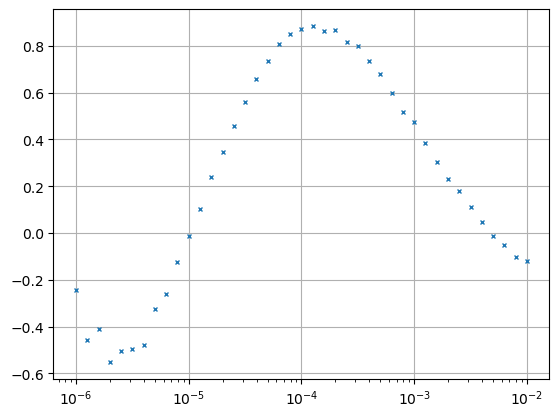

In [67]:
dData = np.log10(dataN) - np.log10(response)
plt.semilogx(time, dData, "x", label="data - response")
plt.grid()

The data difference should be transferred into the model update $\Delta m$, where we again use the logarithm.
For this we need the Jacobian, i.e. how the model response changes when we change the individual layers. Let's do this for a single layer and change it by 10%.

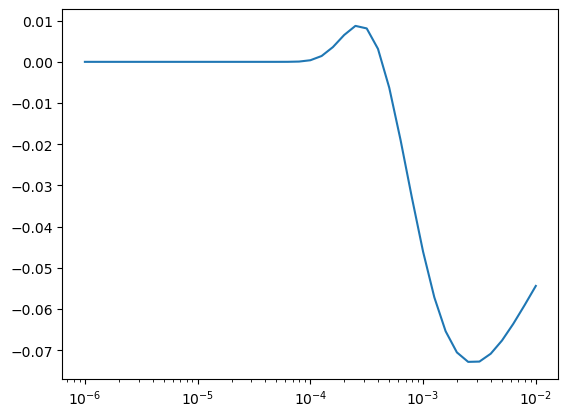

In [68]:
resNew = res.copy()
i = 19
resNew[i] *= 1.1
responseNew = forward(resNew, thk)
sens = (np.log10(responseNew) - np.log10(response)) / (np.log10(resNew[i]) - np.log10(res[i]))
plt.semilogx(time, sens);

An increase in resistivity leads to a decrease of the signal, i.e. a conductivity signal increases the signal (induction).
Let's now do it for all layers and plot the sensitivity matrix. Maybe adapt your model layers and time vectors a bit.

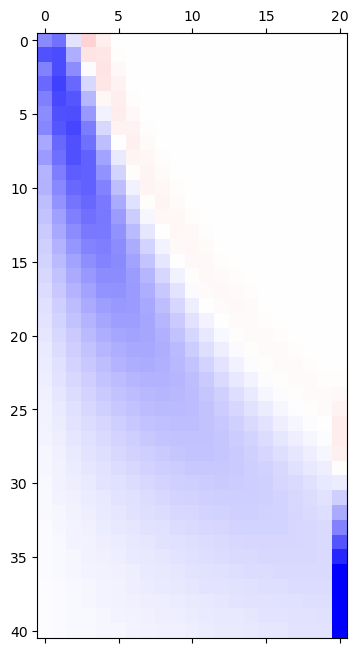

In [69]:
J = np.zeros((len(time), len(res)))
for i in range(len(res)):
    resNew = res.copy()
    resNew[i] *= 1.1
    responseNew = forward(resNew, thk)
    J[:, i] = (np.log10(responseNew) - np.log10(response)) / (np.log10(resNew[i]) - np.log10(res[i]))

plt.matshow(J, cmap="bwr", vmin=-0.5, vmax=0.5)

We can now compute a model update $\Delta m$ from the data misfit using the Jacobian matrix

$$\Rightarrow (\bf J^T\bf J + \lambda \bf C^T\bf C) \Delta\bf m^n = \bf J^T (\bf d-\bf f(\bf m^n)) - \lambda \bf C^T\bf C\bf m^n$$

$$\Delta\bf m^n = (\bf J^T\bf J + \lambda \bf C^T\bf C)^{-1}(\bf J^T (\bf d-\bf f(\bf m^n)) - \lambda \bf C^T\bf C\bf m^n)$$


We just need a regularization matrix $\bf C$ and borrow a smoothness operator from report number 1.
Finally, update the model (take into account that $m=\log \rho$): 
$$m^{n+1}=m^n+\Delta m$$

$$\Rightarrow \rho^{n+1}=e^{m^{n+1}}=e^{m^n+\Delta m}=\rho^n e^{\Delta m}$$
